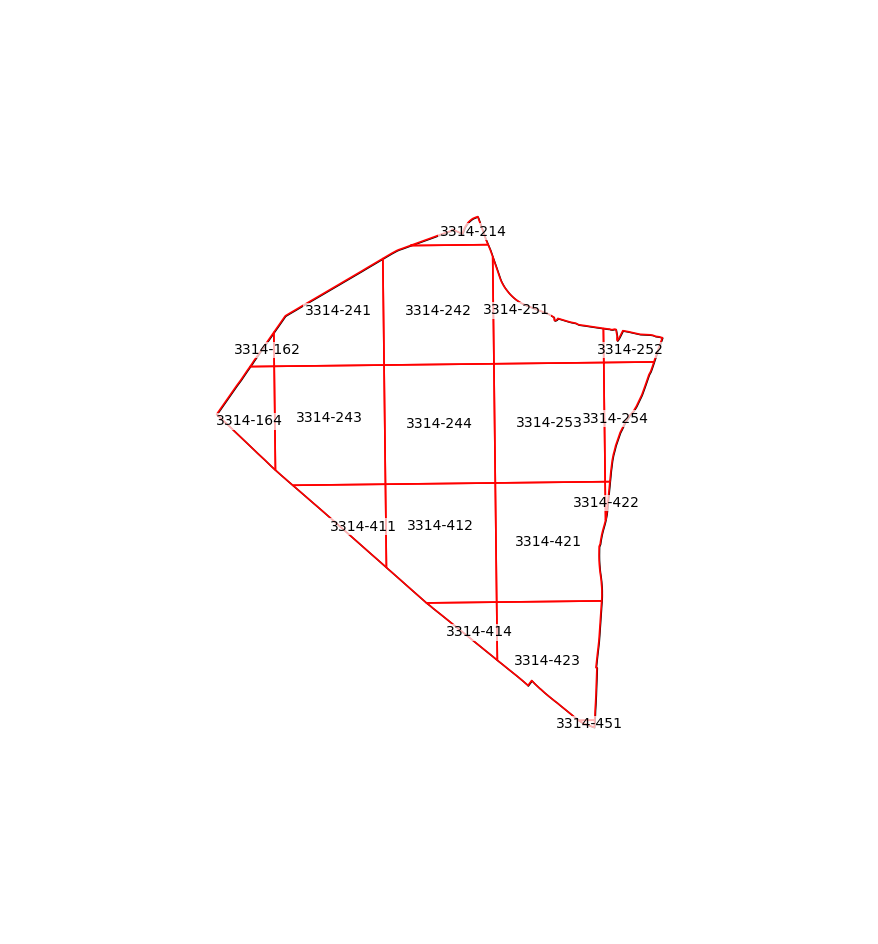

In [2]:
# le o arquivo de distritos na pasta ../downloads abre ele em GPKG e seleciona apenas o bairro da Bela Vista
import geopandas as gpd
import os

# Define o caminho do arquivo
distritos = os.path.join("..", "downloads/SIRGAS_GPKG_distrito.gpkg")

# Lê o arquivo GPKG
gdf_distritos = gpd.read_file(distritos)

# Filtra apenas o bairro da Bela Vista
bela_vista = gdf_distritos["ds_nome"] == "BELA VISTA"
gdf_distritos = gdf_distritos[bela_vista]

# Le o arquivo de articulação de imagens
articulacao = os.path.join("..", "downloads/quadricula_folha_mdt_mds_2020.zip")
gdf_articulacao = gpd.read_file(articulacao)

# Seleciona apenas as imagens que intersectam com o bairro da Bela Vista
gdf_articulacao = gpd.overlay(gdf_articulacao, gdf_distritos, how="intersection")

# Plota o bairro da Bela Vista e as linhas da articulação em vermelho sobrepostas, com o cd_quadric como label
import matplotlib.pyplot as plt

# aumentar o mapa ajustando figsize e extent
minx, miny, maxx, maxy = gdf_distritos.total_bounds
buffer = 1000  # ajuste em metros para expandir a vista
fig, ax = plt.subplots(figsize=(12, 12))

gdf_distritos.plot(ax=ax, color="white", edgecolor="black")
gdf_articulacao.boundary.plot(ax=ax, color="red", linewidth=1.2)

# usa representative_point() para garantir rótulos dentro das feições
rep_pts = gdf_articulacao.geometry.representative_point()
for pt, label in zip(rep_pts, gdf_articulacao["cd_quadric"]):
    ax.text(pt.x, pt.y, label, fontsize=10, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

In [3]:
len(gdf_articulacao)

18

In [4]:
# Caminhos principais
# base_dir = "../../dev/LiDAR-Sampa-2020"
base_dir = "../../LiDAR-Sampa-2020"
output_dir = "resultados/belavista_2020"
os.makedirs(output_dir, exist_ok=True)

In [5]:
# Copia as folhas de articulacao para uma lista de arquivos LAZ
laz_files = []
for index, row in gdf_articulacao.iterrows():
    laz_file = os.path.join(base_dir, f"MDS_{row['cd_quadric']}_1000.laz")
    laz_files.append(laz_file)

In [6]:
laz_files

['../../LiDAR-Sampa-2020/MDS_3314-214_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-252_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-251_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-242_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-241_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-162_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-254_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-253_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-244_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-243_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-164_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-422_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-421_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-412_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-411_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-423_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-414_1000.laz',
 '../../LiDAR-Sampa-2020/MDS_3314-451_1000.laz']

In [8]:
import pdal
import json

# Arquivos LAZ de 2020
print(f"Encontrados {len(laz_files)} arquivos de 2020.")

# Criar lista de leitores PDAL
readers = [{"type": "readers.las", "filename": f} for f in laz_files]

# 4️⃣ Pipeline: merge + crop + salvar
pipeline_json = {
    "pipeline": readers + [
        {"type": "filters.merge"},
        # cortar pelo bounding box
        # cortar pela geometria da favela Paraisópolis
        {"type": "filters.crop", "polygon": gdf_distritos.geometry.to_wkt().values[0]},
        {
            "type": "writers.las",
            "filename": f"{output_dir}/bela_vista_2020_corte.laz"
        },
        {
            "type": "writers.copc",
            "filename": f"{output_dir}/bela_vista_2020_corte.copc.laz"
        }
    ]
}

# 5️⃣ Executar pipeline
p = pdal.Pipeline(json.dumps(pipeline_json))
p.execute()

print("✅ Arquivo LAZ unificado e recortado gerado em:")
print(f"   {output_dir}/bela_vista_2020_corte.copc.laz")

Encontrados 18 arquivos de 2020.
✅ Arquivo LAZ unificado e recortado gerado em:
   resultados/belavista_2020/bela_vista_2020_corte.copc.laz
